In [1]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '-1' # don't use GPU
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' #omit info

from learnMSA.align import AlignmentModel
from learnMSA.util import SequenceDataset
from learnMSA.util.visualize import plot_phmm

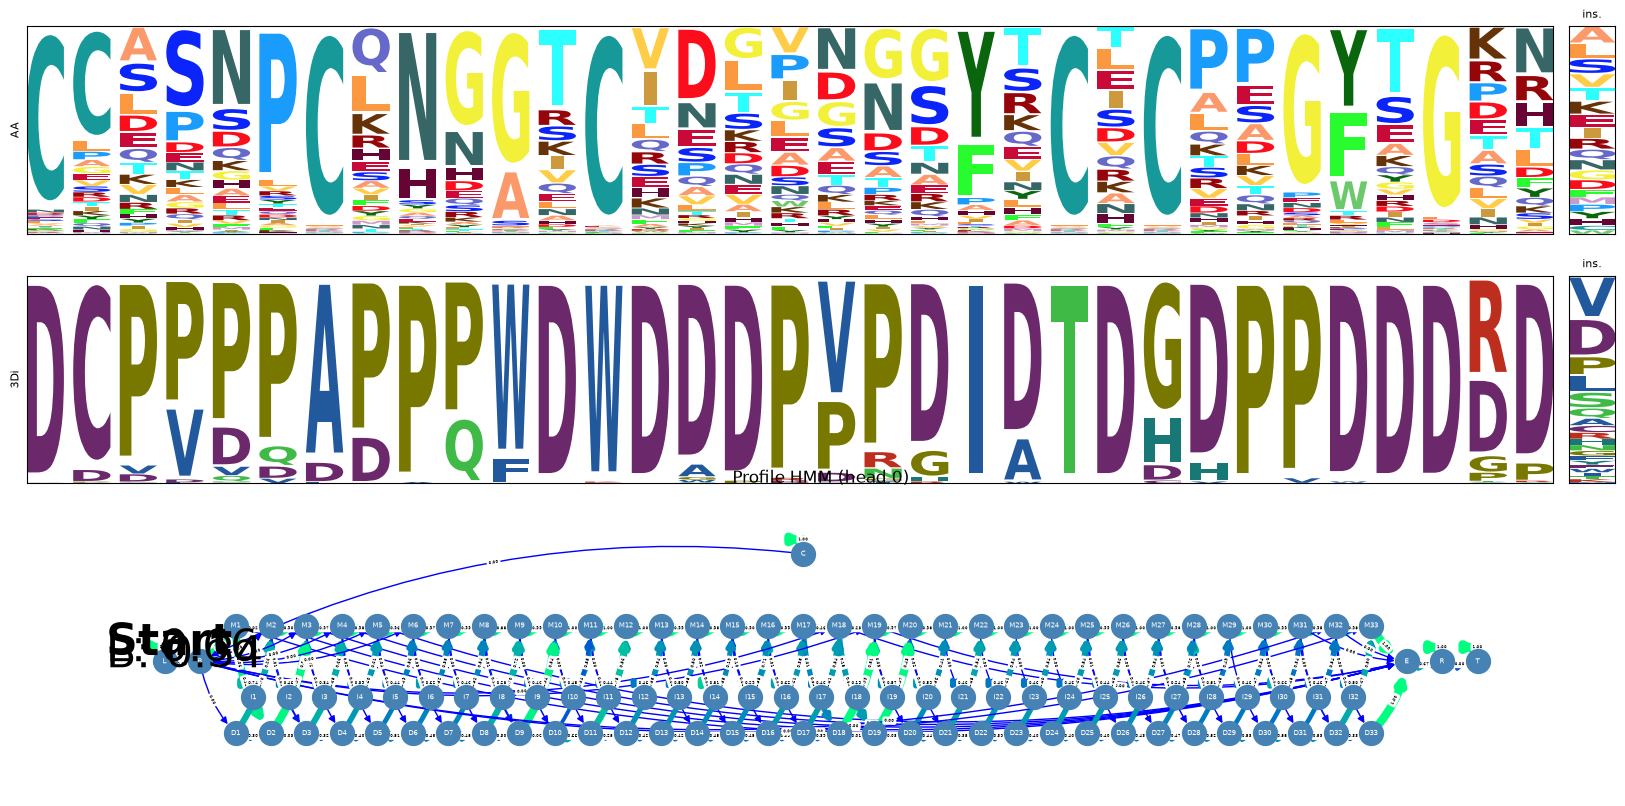

In [2]:
# Model built with:
# learnMSA --from_msa egf.ref
# --skip_training --no_noise --save_model egf.model
model_path = "../tmp/egf.model"
data_path = "../../snakeMSA/data/homfam/unaligned/egf.vie"

data = SequenceDataset(data_path)
alignment_model = AlignmentModel.load(model_path, data)

fig=plot_phmm(alignment_model.model.phmm_layer, head = 0, fast_mode = True)

In [10]:
alignment_model.model.phmm_layer.struct_emitter.temperature = 1.0
B = alignment_model.model.phmm_layer.struct_emitter.matrix()[0, 0].detach().numpy()
alignment_model.model.phmm_layer.struct_emitter.temperature = 8.0
B8 = alignment_model.model.phmm_layer.struct_emitter.matrix()[0, 0].detach().numpy()
B, B8

(array([1.05975283e-04, 2.22438452e-04, 9.96896744e-01, 6.65889456e-05,
        7.91548737e-05, 8.53735619e-05, 8.97546270e-05, 6.09526724e-05,
        5.42233902e-05, 2.85475020e-04, 2.29270026e-05, 9.78809912e-05,
        5.23401075e-04, 1.52206732e-04, 1.10254034e-04, 2.80064793e-04,
        5.72156277e-05, 6.76432101e-04, 6.52000017e-05, 6.76124109e-05],
       dtype=float32),
 array([0.04470082, 0.04904177, 0.14028013, 0.04217841, 0.04309973,
        0.04350912, 0.04378214, 0.04171469, 0.04110912, 0.05059538,
        0.03691546, 0.04425906, 0.0545782 , 0.04677019, 0.04492253,
        0.05047452, 0.04138607, 0.05635636, 0.04206742, 0.0422589 ],
       dtype=float32))

1.0

In [ ]:
fig.savefig("egf_phmm.pdf", bbox_inches="tight") # type: ignore